# Kazakh AI-Text Detection — KerasNLP (v5: full fine-tuning)

Three-way task: **0 = Human**, **1 = AI-Generated**, **2 = AI-Obfuscated**.

This version keeps a single training strategy — **full fine-tuning** of every backbone (no frozen/partial
regimes). Backbones: XLM-R, mDeBERTa-v3, mBERT, DistilmBERT, plus a TF-IDF + Logistic Regression reference
baseline. We report accuracy, macro-F1 and per-class F1, quantify uncertainty (bootstrap CIs), test significance
(McNemar, Holm-corrected), and archive every figure/table to one ZIP. Figures are saved at **dpi=300** (PNG+PDF)
with on-figure titles omitted (put them in the captions).


In [ ]:
# ---------------------------------------------------------------------------
# 0. Install dependencies
# ---------------------------------------------------------------------------
INSTALL_DEPS = True
if INSTALL_DEPS:
    import subprocess, sys
    pkgs = ['keras>=3.3', 'keras-nlp>=0.14', 'scikit-learn', 'matplotlib', 'seaborn', 'scipy', 'pandas']
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-U', *pkgs], check=False)
    print('Dependencies installed.')

Dependencies installed.


In [ ]:
# ---------------------------------------------------------------------------
# 1. Backend + imports + reproducibility (choose backend BEFORE importing keras)
# ---------------------------------------------------------------------------
import os
BACKEND = 'jax'
os.environ['KERAS_BACKEND'] = BACKEND
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import json, gc, random, shutil, warnings, itertools
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import softmax
import tensorflow as tf

import keras
try:
    import keras_nlp
except Exception:
    import keras_hub as keras_nlp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix,
                             roc_auc_score)

warnings.filterwarnings('ignore')
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
keras.utils.set_random_seed(GLOBAL_SEED)

print('Keras:', keras.__version__, '| backend:', keras.backend.backend())
print('KerasNLP:', keras_nlp.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', bool(gpus))
if gpus:
    try:
        keras.mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision: mixed_float16')
    except Exception as e:
        print('Mixed precision unavailable:', e)


Keras: 3.15.0 | backend: jax
KerasNLP: 0.29.1
GPU available: True
Mixed precision: mixed_float16


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---------------------------------------------------------------------------
# 2. Configuration
# ---------------------------------------------------------------------------
DATA_PATHS = {
    'train': '/content/drive/MyDrive/IEEE ACCESS/data/interim/train_cleaned.json',
    'dev':   '/content/drive/MyDrive/IEEE ACCESS/data/interim/dev_cleaned.json',
    'test':  '/content/drive/MyDrive/IEEE ACCESS/data/interim/test_cleaned.json',
}

SEQ_LEN = 256
EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 2e-5              # full fine-tuning
WEIGHT_DECAY = 0.01
SEEDS = [42, 1, 2]                     # add more seeds (e.g. [42, 1, 2]) for mean +/- std
BOOTSTRAP_N = 1000
INCLUDE_LR_BASELINE = True

LABELS = [0, 1, 2]
TARGET_NAMES = ['Human', 'AI-Generated', 'AI-Obfuscated']
ID2LABEL = {0: 'Human', 1: 'AI-Generated', 2: 'AI-Obfuscated'}
PALETTE = {'Human': '#2E86AB', 'AI-Generated': '#E4572E', 'AI-Obfuscated': '#8FB339'}

KNLP_MODELS = {
    'XLM-R (base)':       ('xlm_roberta', 'xlm_roberta_base_multi'),
    'mDeBERTa-v3 (base)': ('deberta_v3',  'deberta_v3_base_multi'),
    'mBERT (cased)':      ('bert',        'bert_base_multi'),
    'DistilmBERT':        ('distil_bert', 'distil_bert_base_multi'),
}

sns.set_theme(style='whitegrid', context='paper')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'

RESULTS_DIR = Path('results')
FIG_DIR = RESULTS_DIR / 'figures'
TAB_DIR = RESULTS_DIR / 'tables'
PRED_DIR = RESULTS_DIR / 'predictions'
MET_DIR = RESULTS_DIR / 'metrics'
for _d in (RESULTS_DIR, FIG_DIR, TAB_DIR, PRED_DIR, MET_DIR):
    _d.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png', dpi=300)
    print('[fig]', FIG_DIR / f'{name}.png')

def save_table(df, name, index=True):
    df.to_csv(TAB_DIR / f'{name}.csv', index=index)
    print('[tab]', TAB_DIR / f'{name}.csv')

def safe_name(name):
    for a, b in [(' ', '_'), ('/', '-'), ('(', ''), (')', ''), (',', '')]:
        name = name.replace(a, b)
    return name

print('Config ready | models:', list(KNLP_MODELS), '| seeds:', SEEDS, '| epochs:', EPOCHS)


Config ready | models: ['XLM-R (base)', 'mDeBERTa-v3 (base)', 'mBERT (cased)', 'DistilmBERT'] | seeds: [42, 1, 2] | epochs: 5


## 1. Load data + dedup/leakage sanity check


In [ ]:
def find_file(fname):
    for c in [Path(fname), Path('..') / fname, Path('data') / fname, Path('clean_data') / fname]:
        if c.exists():
            return c
    return Path(fname)

def load_split(fname, split):
    with open(find_file(fname), 'r', encoding='utf-8') as f:
        df = pd.DataFrame(json.load(f))
    df['split'] = split
    df['text'] = df['text'].astype(str)
    df['label'] = df['label'].astype(int)
    return df

train_df = load_split(DATA_PATHS['train'], 'train')
dev_df = load_split(DATA_PATHS['dev'], 'dev')
test_df = load_split(DATA_PATHS['test'], 'test')
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
full_df['label_name'] = full_df['label'].map(ID2LABEL)

y_train = train_df['label'].to_numpy().astype('int32')
y_dev = dev_df['label'].to_numpy().astype('int32')
y_test = test_df['label'].to_numpy().astype('int32')
print('Split sizes:', {'train': len(train_df), 'dev': len(dev_df), 'test': len(test_df)})

def norm_key(t):
    return ''.join(ch for ch in t.lower() if ch.isalnum())

ksets = {s: set(d['text'].map(norm_key)) for s, d in [('train', train_df), ('dev', dev_df), ('test', test_df)]}
ov = {'train/dev': len(ksets['train'] & ksets['dev']), 'train/test': len(ksets['train'] & ksets['test']),
      'dev/test': len(ksets['dev'] & ksets['test'])}
print('Cross-split exact-text overlaps:', ov)
if sum(ov.values()) > 0:
    print('WARNING: cross-split leakage -> use the deduplicated cleaned files!')
if len(train_df) > 5000:
    print('WARNING: train has >5000 rows -> looks like the ORIGINAL (non-deduplicated) split.')
print('\nTrain class balance:')
print(train_df['label'].map(ID2LABEL).value_counts().reindex(TARGET_NAMES))


Split sizes: {'train': 4198, 'dev': 900, 'test': 900}
Cross-split exact-text overlaps: {'train/dev': 0, 'train/test': 0, 'dev/test': 0}

Train class balance:
label
Human            1609
AI-Generated     1889
AI-Obfuscated     700
Name: count, dtype: int64


[fig] results/figures/fig1_dataset_overview.png


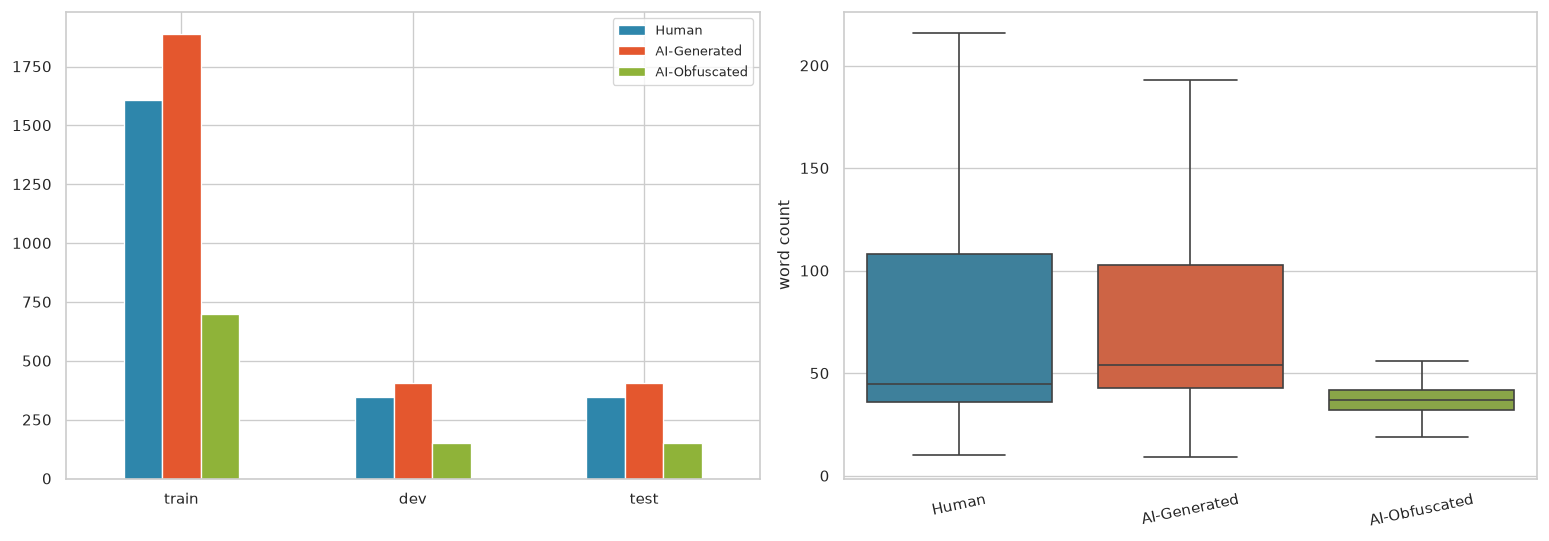

[tab] results/tables/table1_dataset_composition.csv


In [ ]:
# ---- Figure 1: class distribution + length by class (titles in caption) ----
full_df['n_words'] = full_df['text'].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ct = pd.crosstab(full_df['split'], full_df['label_name']).reindex(index=['train', 'dev', 'test'], columns=TARGET_NAMES)
ct.plot(kind='bar', ax=axes[0], color=[PALETTE[c] for c in TARGET_NAMES])
# ax title omitted (caption): '(a) Class counts by split'
axes[0].set_xlabel(''); axes[0].tick_params(axis='x', labelrotation=0); axes[0].legend(fontsize=8)
sns.boxplot(data=full_df, x='label_name', y='n_words', order=TARGET_NAMES, palette=PALETTE, showfliers=False, ax=axes[1])
# ax title omitted (caption): '(b) Word-count by class'
axes[1].set_xlabel(''); axes[1].set_ylabel('word count'); axes[1].tick_params(axis='x', labelrotation=12)
fig.tight_layout(); save_fig(fig, 'fig1_dataset_overview'); plt.show()
comp = ct.copy(); comp['Total'] = comp.sum(axis=1); comp.loc['Total'] = comp.sum(axis=0)
save_table(comp, 'table1_dataset_composition')


## 2. Evaluation utilities


In [ ]:
RESULTS, PREDS, PROBS, HISTORIES, SEED_SCORES = {}, {}, {}, {}, {}

def evaluate_predictions(name, y_true, y_pred, y_prob):
    per_class = f1_score(y_true, y_pred, average=None, labels=LABELS)
    metrics = {'model': name,
               'accuracy': accuracy_score(y_true, y_pred),
               'macro_f1': f1_score(y_true, y_pred, average='macro'),
               'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
               'f1_Human': per_class[0], 'f1_AI-Generated': per_class[1], 'f1_AI-Obfuscated': per_class[2]}
    try:
        metrics['roc_auc_ovr'] = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        metrics['roc_auc_ovr'] = np.nan
    RESULTS[name] = metrics
    PREDS[name] = np.asarray(y_pred)
    PROBS[name] = np.asarray(y_prob)
    pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).to_csv(PRED_DIR / f'preds_{safe_name(name)}.csv', index=False)
    with open(TAB_DIR / f'report_{safe_name(name)}.txt', 'w', encoding='utf-8') as f:
        f.write(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=4))
    print(f'  -> {name}: acc={metrics["accuracy"]:.4f} | macro-F1={metrics["macro_f1"]:.4f}')
    return metrics


## 3. Reference baseline — TF-IDF + Logistic Regression


In [ ]:
if INCLUDE_LR_BASELINE:
    vectorizer = FeatureUnion([
        ('word', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=3, sublinear_tf=True, max_features=10000)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True, max_features=20000)),
    ])
    Xtr = vectorizer.fit_transform(train_df['text'])
    Xdv = vectorizer.transform(dev_df['text'])
    Xte = vectorizer.transform(test_df['text'])
    best_C, best_f1 = 1.0, -1.0
    for C in [0.25, 0.5, 1.0, 2.0, 5.0]:
        clf = LogisticRegression(C=C, max_iter=2000, class_weight='balanced', n_jobs=-1).fit(Xtr, y_train)
        f1 = f1_score(y_dev, clf.predict(Xdv), average='macro')
        if f1 > best_f1:
            best_f1, best_C = f1, C
    print(f'Best C = {best_C} (dev macro-F1 = {best_f1:.4f})')
    lr = LogisticRegression(C=best_C, max_iter=3000, class_weight='balanced', n_jobs=-1).fit(Xtr, y_train)
    m = evaluate_predictions('TF-IDF + LogReg', y_test, lr.predict(Xte), lr.predict_proba(Xte))
    SEED_SCORES['TF-IDF + LogReg'] = [{'macro_f1': m['macro_f1']}]
else:
    print('LR baseline disabled.')


Best C = 5.0 (dev macro-F1 = 0.8141)
  -> TF-IDF + LogReg: acc=0.7711 | macro-F1=0.7757


## 4. KerasNLP pipeline & model builder

Raw strings are fed via `tf.data`; the KerasNLP task models tokenize internally. Every backbone is **fully
fine-tuned** (all layers trainable, the default).


In [ ]:
def make_ds(texts, labels, shuffle, seed=GLOBAL_SEED, batch=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((list(texts), labels.astype('int32')))
    if shuffle:
        ds = ds.shuffle(len(labels), seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

dev_ds = make_ds(dev_df['text'], y_dev, shuffle=False)
test_ds = make_ds(test_df['text'], y_test, shuffle=False)

cw = compute_class_weight('balanced', classes=np.array(LABELS), y=y_train)
class_weight = {int(k): float(v) for k, v in zip(LABELS, cw)}
print('Class weights:', class_weight)

_REG = {
    'xlm_roberta': ('XLMRobertaClassifier', 'XLMRobertaPreprocessor'),
    'deberta_v3':  ('DebertaV3Classifier', 'DebertaV3Preprocessor'),
    'bert':        ('BertClassifier', 'BertPreprocessor'),
    'distil_bert': ('DistilBertClassifier', 'DistilBertPreprocessor'),
}

def build_classifier(family, preset, num_classes, seq_len):
    clf_name, pre_name = _REG[family]
    PreCls = getattr(keras_nlp.models, pre_name)
    ClfCls = getattr(keras_nlp.models, clf_name)
    pre = PreCls.from_preset(preset, sequence_length=seq_len)
    return ClfCls.from_preset(preset, num_classes=num_classes, preprocessor=pre)


Class weights: {0: 0.8696913196602445, 1: 0.7407799541203458, 2: 1.999047619047619}


## 5. Fine-tune every backbone (full fine-tuning, seed-ensembled)

Each model is trained once per seed; the seeds' softmax probabilities are averaged into the reported prediction.
**Cost:** `len(models) x len(SEEDS)` fine-tuning runs. Sessions are cleared between runs to free GPU memory.


In [ ]:
def train_one(family, preset, seed):
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)
    clf = build_classifier(family, preset, num_classes=3, seq_len=SEQ_LEN)   # all layers trainable (full)
    clf.compile(optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    tr = make_ds(train_df['text'], y_train, shuffle=True, seed=seed)
    cbs = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    hist = clf.fit(tr, validation_data=dev_ds, epochs=EPOCHS, class_weight=class_weight, callbacks=cbs, verbose=1)
    logits = clf.predict(test_ds, verbose=0)
    probs = softmax(np.asarray(logits), axis=1)
    del clf; gc.collect()
    return probs, hist.history

def run_model(base, family, preset):
    print(f'\n===== {base} (full fine-tune) =====')
    seed_probs, seed_scores = [], []
    for sd in SEEDS:
        print(f'--- {base} | seed {sd} ---')
        try:
            probs, hist = train_one(family, preset, sd)
        except Exception as e:
            print(f'  [SKIP seed {sd}] {type(e).__name__}: {e}')
            continue
        seed_probs.append(probs)
        p = probs.argmax(1)
        seed_scores.append({'seed': sd, 'macro_f1': f1_score(y_test, p, average='macro'),
                            'accuracy': accuracy_score(y_test, p)})
        HISTORIES.setdefault(base, hist)
    if not seed_probs:
        print(f'  [SKIP] {base}: no successful runs')
        return
    ens = np.mean(seed_probs, axis=0)
    evaluate_predictions(base, y_test, ens.argmax(1), ens)
    SEED_SCORES[base] = seed_scores

for base, (family, preset) in KNLP_MODELS.items():
    try:
        run_model(base, family, preset)
    except Exception as e:
        print(f'[SKIP] {base} failed: {type(e).__name__}: {e}')
print('\nModels evaluated:', list(RESULTS.keys()))



===== XLM-R (base) (full fine-tune) =====
--- XLM-R (base) | seed 42 ---
Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.4516 - loss: 0.9246 - val_accuracy: 0.5978 - val_loss: 0.7799
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 236s 887ms/step - accuracy: 0.6887 - loss: 0.5775 - val_accuracy: 0.8067 - val_loss: 0.4435
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 232s 869ms/step - accuracy: 0.8097 - loss: 0.3564 - val_accuracy: 0.8467 - val_loss: 0.3330
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 230s 863ms/step - accuracy: 0.8737 - loss: 0.2636 - val_accuracy: 0.8500 - val_loss: 0.3931
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 234s 881ms/step - accuracy: 0.9304 - loss: 0.1555 - val_accuracy: 0.9000 - val_loss: 0.2354
--- XLM-R (base) | seed 1 ---
Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 289s 993ms/step - accuracy: 0.4840 - loss: 0.8985 - val_accuracy: 0.6122 - val_loss: 0.7206
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 234s 876ms/step - accuracy: 0.6343 - loss: 0.6220 - val_accuracy: 0.7300 -

100%|██████████| 487/487 [00:00<00:00, 1.35MB/s]


100%|██████████| 614/614 [00:00<00:00, 1.07MB/s]


100%|██████████| 4.11M/4.11M [00:00<00:00, 176MB/s]


100%|██████████| 1.04G/1.04G [00:15<00:00, 71.7MB/s]


...

100%|██████████| 972k/972k [00:00<00:00, 102MB/s]


100%|██████████| 679M/679M [00:07<00:00, 99.0MB/s]


Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 290s 993ms/step - accuracy: 0.6332 - loss: 0.6587 - val_accuracy: 0.7589 - val_loss: 0.5100
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 230s 865ms/step - accuracy: 0.8054 - loss: 0.3709 - val_accuracy: 0.8789 - val_loss: 0.3114
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 229s 859ms/step - accuracy: 0.8811 - loss: 0.2418 - val_accuracy: 0.8700 - val_loss: 0.3586
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 230s 863ms/step - accuracy: 0.9283 - loss: 0.1630 - val_accuracy: 0.8533 - val_loss: 0.3947
--- mBERT (cased) | seed 1 ---
Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 288s 983ms/step - accuracy: 0.6622 - loss: 0.6459 - val_accuracy: 0.8178 - val_loss: 0.4604
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 231s 867ms/step - accuracy: 0.8066 - loss: 0.3861 - val_accuracy: 0.8578 - val_loss: 0.3637
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 231s 867ms/step - accuracy: 0.8702 - loss: 0.2629 - val_accuracy: 0.8544 - val_loss: 0.3636
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 231s 870ms/st

100%|██████████| 463/463 [00:00<00:00, 1.34MB/s]


Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 150s 510ms/step - accuracy: 0.5643 - loss: 0.7641 - val_accuracy: 0.7500 - val_loss: 0.5631
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 120s 446ms/step - accuracy: 0.7463 - loss: 0.4664 - val_accuracy: 0.8167 - val_loss: 0.4493
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 152s 569ms/step - accuracy: 0.8378 - loss: 0.3272 - val_accuracy: 0.8511 - val_loss: 0.3777
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 119s 443ms/step - accuracy: 0.8880 - loss: 0.2292 - val_accuracy: 0.8322 - val_loss: 0.4493
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 117s 436ms/step - accuracy: 0.9245 - loss: 0.1786 - val_accuracy: 0.8567 - val_loss: 0.3949
--- DistilmBERT | seed 1 ---
Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 148s 501ms/step - accuracy: 0.5841 - loss: 0.7410 - val_accuracy: 0.7367 - val_loss: 0.5683
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 119s 445ms/step - accuracy: 0.7437 - loss: 0.4845 - val_accuracy: 0.8167 - val_loss: 0.4197
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 118s 439ms/step

[fig] results/figures/fig2_training_curves.png


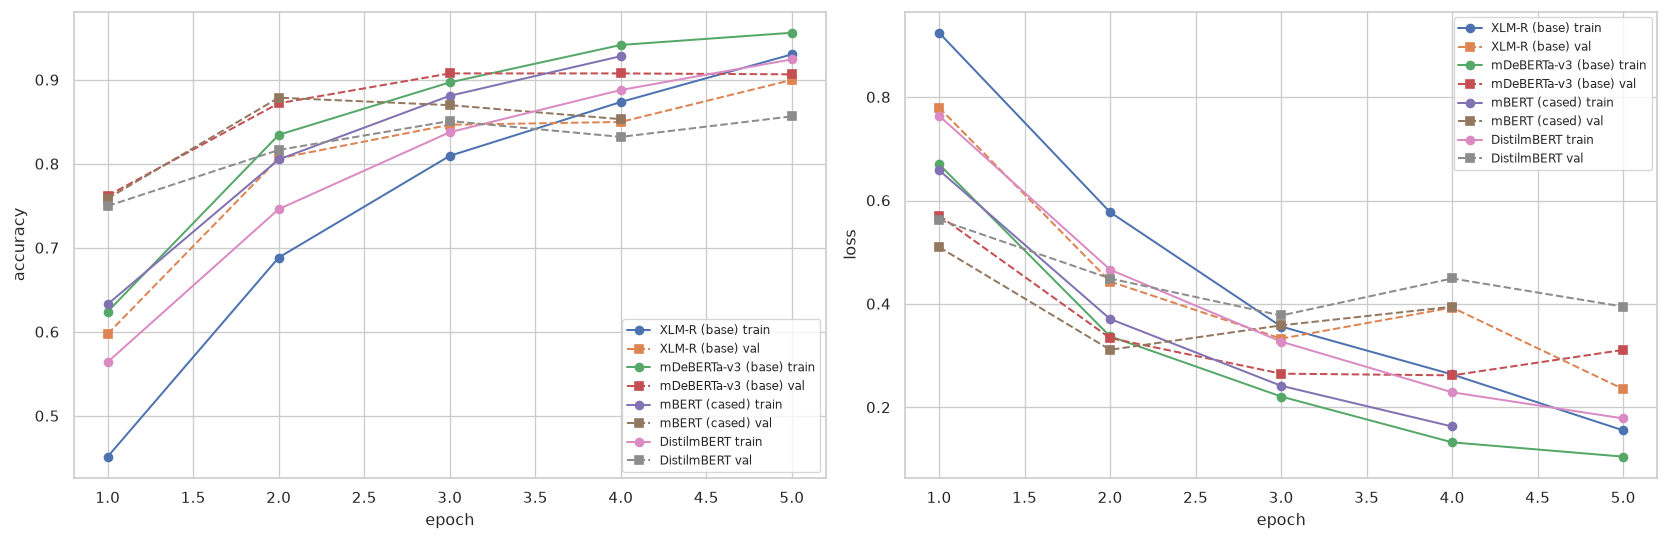

In [ ]:
# ---- Figure 2: training curves ----
if HISTORIES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    for base, h in HISTORIES.items():
        ep = range(1, len(h['loss']) + 1)
        axes[0].plot(ep, h.get('accuracy', []), marker='o', label=f'{base} train')
        if 'val_accuracy' in h:
            axes[0].plot(ep, h['val_accuracy'], marker='s', linestyle='--', label=f'{base} val')
        axes[1].plot(ep, h['loss'], marker='o', label=f'{base} train')
        if 'val_loss' in h:
            axes[1].plot(ep, h['val_loss'], marker='s', linestyle='--', label=f'{base} val')
    # ax titles omitted (caption): accuracy / loss per epoch
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('accuracy')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('loss')
    axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
    fig.tight_layout(); save_fig(fig, 'fig2_training_curves'); plt.show()
else:
    print('No transformer histories to plot.')


## 6. Results


In [ ]:
results_df = pd.DataFrame(RESULTS).T.reset_index(drop=True)
# per-seed mean/std (std=0 for single-seed or deterministic baseline)
var_rows = []
for name, scores in SEED_SCORES.items():
    a = np.array([s['macro_f1'] for s in scores])
    var_rows.append({'model': name, 'n_runs': len(a),
                     'macroF1_seed_mean': round(float(a.mean()), 4), 'macroF1_seed_std': round(float(a.std()), 4)})
results_df = results_df.merge(pd.DataFrame(var_rows), on='model', how='left')
num_cols = ['accuracy', 'macro_f1', 'weighted_f1', 'f1_Human', 'f1_AI-Generated', 'f1_AI-Obfuscated', 'roc_auc_ovr']
results_df[num_cols] = results_df[num_cols].astype(float).round(4)
results_df = results_df.sort_values('macro_f1', ascending=False).reset_index(drop=True)
save_table(results_df, 'table2_overall_results', index=False)
results_df


[tab] results/tables/table2_overall_results.csv


,model,accuracy,macro_f1,weighted_f1,f1_Human,f1_AI-Generated,f1_AI-Obfuscated,roc_auc_ovr,n_runs,macroF1_seed_mean,macroF1_seed_std
0,mDeBERTa-v3 (base),0.9089,0.9170,0.9088,0.8971,0.9031,0.9508,0.9855,3,0.9009,0.0075
1,XLM-R (base),0.9056,0.9151,0.9054,0.8942,0.8968,0.9542,0.9813,3,0.8834,0.0193
2,mBERT (cased),0.8911,0.9009,0.8911,0.8800,0.8823,0.9404,0.9751,3,0.8758,0.0139
3,DistilmBERT,0.8567,0.8689,0.8561,0.8427,0.8439,0.9201,0.9606,3,0.8426,0.0120
4,TF-IDF + LogReg,0.7711,0.7757,0.7713,0.7568,0.7744,0.7960,0.9165,1,0.7757,0.0000


[fig] results/figures/fig3_model_comparison.png


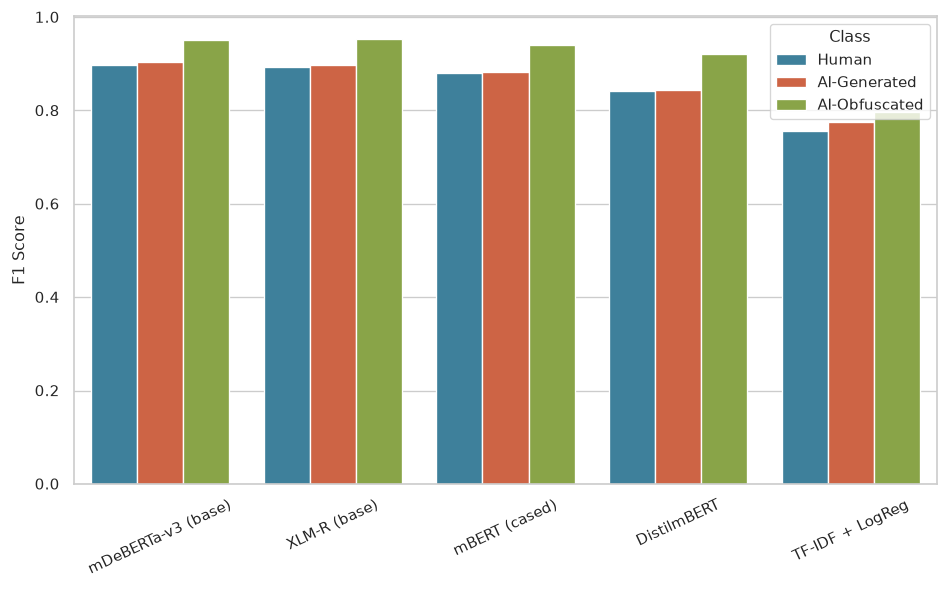

In [ ]:
# ---- Per-class F1 comparison ----
order = results_df['model'].tolist()

melted = results_df.melt(
    id_vars='model',
    value_vars=['f1_Human', 'f1_AI-Generated', 'f1_AI-Obfuscated'],
    var_name='class',
    value_name='f1'
)

melted['class'] = melted['class'].str.replace('f1_', '', regex=False)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=melted,
    x='model',
    y='f1',
    hue='class',
    order=order,
    palette=PALETTE,
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('F1 Score')
ax.tick_params(axis='x', labelrotation=25)
ax.legend(title='Class', fontsize=9)

fig.tight_layout()
save_fig(fig, 'fig3_model_comparison')
plt.show()

[fig] results/figures/fig4_confusion_matrices.png


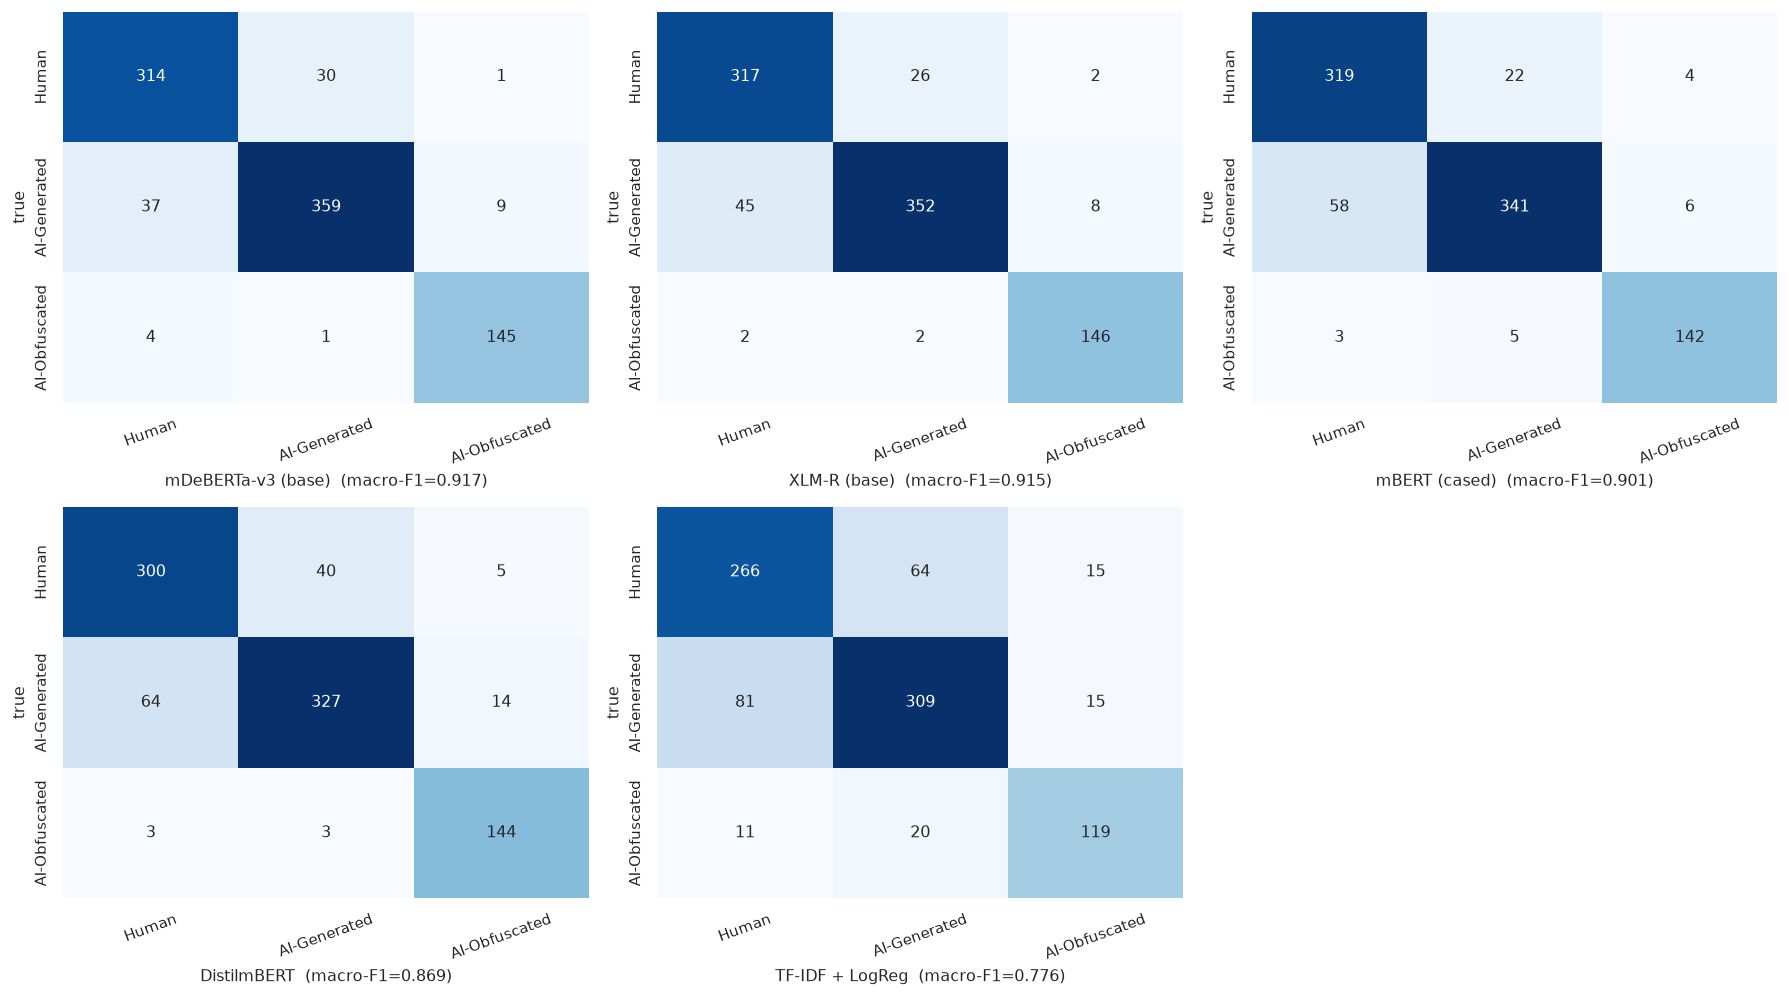

In [ ]:
# ---- Figure 4: confusion matrices ----
names_all = list(results_df['model'])
ncols = min(3, len(names_all)); nrows = int(np.ceil(len(names_all) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.2 * nrows))
axes = np.array(axes).reshape(-1)
for ax, name in zip(axes, names_all):
    cm = confusion_matrix(y_test, PREDS[name], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_NAMES,
                yticklabels=TARGET_NAMES, ax=ax, cbar=False)
    ax.set_xlabel(f'{name}  (macro-F1={RESULTS[name]["macro_f1"]:.3f})')
    ax.set_ylabel('true'); ax.tick_params(axis='x', labelrotation=20)
for j in range(len(names_all), len(axes)):
    axes[j].axis('off')
fig.tight_layout(); save_fig(fig, 'fig4_confusion_matrices'); plt.show()


## 7. Statistical analysis (bootstrap CIs + McNemar, Holm-corrected)


[tab] results/tables/table3_bootstrap_ci.csv
             model  macro_f1_mean  ci95_low  ci95_high
mDeBERTa-v3 (base)         0.9168    0.8989     0.9351
      XLM-R (base)         0.9150    0.8973     0.9318
     mBERT (cased)         0.9005    0.8806     0.9196
       DistilmBERT         0.8688    0.8460     0.8892
   TF-IDF + LogReg         0.7757    0.7466     0.8023
[fig] results/figures/fig5_bootstrap_ci.png


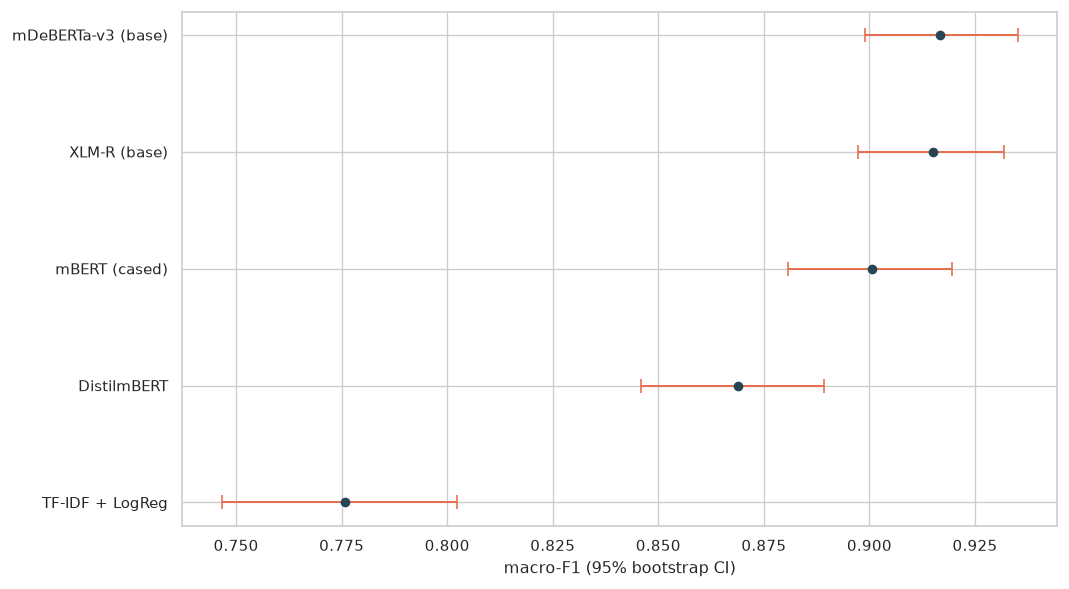

In [ ]:
def bootstrap_macro_f1(y_true, y_pred, n=BOOTSTRAP_N, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    sc = np.array([f1_score(y_true[s], y_pred[s], average='macro')
                   for s in (rng.choice(idx, size=len(idx), replace=True) for _ in range(n))])
    return sc.mean(), np.percentile(sc, 2.5), np.percentile(sc, 97.5)

boot = []
for name in results_df['model']:
    mean, lo, hi = bootstrap_macro_f1(y_test, PREDS[name])
    boot.append({'model': name, 'macro_f1_mean': round(mean, 4), 'ci95_low': round(lo, 4), 'ci95_high': round(hi, 4)})
boot_df = pd.DataFrame(boot)
save_table(boot_df, 'table3_bootstrap_ci', index=False)
print(boot_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 0.7 * len(boot_df) + 1.5))
yv = np.arange(len(boot_df))[::-1]
ax.errorbar(boot_df['macro_f1_mean'], yv,
            xerr=[boot_df['macro_f1_mean'] - boot_df['ci95_low'], boot_df['ci95_high'] - boot_df['macro_f1_mean']],
            fmt='o', color='#264653', ecolor='#e76f51', capsize=4)
ax.set_yticks(yv); ax.set_yticklabels(boot_df['model']); ax.set_xlabel('macro-F1 (95% bootstrap CI)')
# ax title omitted (caption)
fig.tight_layout(); save_fig(fig, 'fig5_bootstrap_ci'); plt.show()


In [ ]:
def mcnemar_test(y_true, pa, pb):
    a_ok, b_ok = (pa == y_true), (pb == y_true)
    n01 = int(np.sum(a_ok & ~b_ok)); n10 = int(np.sum(~a_ok & b_ok)); n = n01 + n10
    if n == 0:
        return 1.0, 0.0, n01, n10
    if n < 25:
        return stats.binomtest(min(n01, n10), n, 0.5).pvalue, float(min(n01, n10)), n01, n10
    statv = (abs(n01 - n10) - 1) ** 2 / n
    return stats.chi2.sf(statv, 1), statv, n01, n10

names_all = list(results_df['model'])
if len(names_all) > 1:
    rows = []
    for a, b in itertools.combinations(names_all, 2):
        p, statv, n01, n10 = mcnemar_test(y_test, PREDS[a], PREDS[b])
        rows.append({'model_A': a, 'model_B': b, 'A_only_correct': n01, 'B_only_correct': n10,
                     'statistic': round(statv, 3), 'p_raw': p})
    mc = pd.DataFrame(rows)
    oi = mc['p_raw'].to_numpy().argsort(); mm = len(mc); holm = np.empty(mm); prev = 0.0
    for rank, i in enumerate(oi):
        prev = max(prev, min(1.0, (mm - rank) * mc['p_raw'].iloc[i])); holm[i] = prev
    mc['p_holm'] = holm.round(4); mc['significant_0.05'] = mc['p_holm'] < 0.05; mc['p_raw'] = mc['p_raw'].round(4)
    save_table(mc, 'table4_mcnemar_holm', index=False)
    print(mc.to_string(index=False))
else:
    print('Need >=2 models for McNemar tests.')


[tab] results/tables/table4_mcnemar_holm.csv
           model_A         model_B  A_only_correct  B_only_correct  statistic  p_raw  p_holm  significant_0.05
mDeBERTa-v3 (base)    XLM-R (base)              40              37      0.052 0.8197  0.8197             False
mDeBERTa-v3 (base)   mBERT (cased)              49              33      2.744 0.0976  0.2929             False
mDeBERTa-v3 (base)     DistilmBERT              79              32     19.063 0.0000  0.0001              True
mDeBERTa-v3 (base) TF-IDF + LogReg             159              35     77.985 0.0000  0.0000              True
      XLM-R (base)   mBERT (cased)              52              39      1.582 0.2084  0.4168             False
      XLM-R (base)     DistilmBERT              80              36     15.940 0.0001  0.0003              True
      XLM-R (base) TF-IDF + LogReg             157              36     74.611 0.0000  0.0000              True
     mBERT (cased)     DistilmBERT              65              34 

## 8. Error analysis — length-stratified macro-F1 + misclassified examples


[tab] results/tables/table5_length_stratified_f1.csv
[fig] results/figures/fig6_length_stratified_f1.png


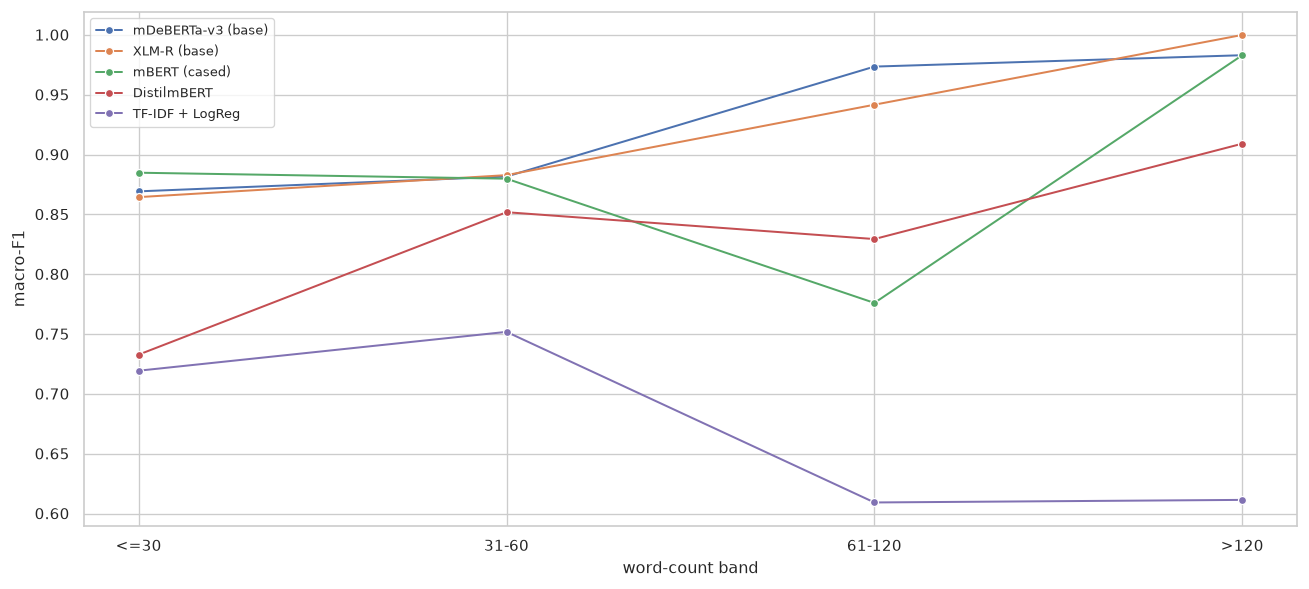

Best model: mDeBERTa-v3 (base) | misclassified: 82/900


,true,pred,source,text_preview
41,Human,AI-Generated,Summary,Президент Қасым-Жомарт Тоқаев халыққа Жолдауын...
60,Human,AI-Generated,Summary,АЭС тек энергетикалық сұранысты қанағаттандыры...
178,AI-Generated,Human,Summary,Мемлекет басшысы Қасым-Жомарт Тоқаев Алматы об...
205,AI-Generated,Human,Summary,ҚР премьер-министрінің орынбасары Қанат Бозымб...
221,AI-Generated,Human,Summary,"Азық-түлікті сақтау - өнімнің мерзімін ұзарту,..."
273,AI-Generated,Human,Conversion,Қоғамдық кеңестер мемлекеттік органдар мен аза...
280,AI-Generated,Human,Summary,Адамзаттың қарқынды дамуы мен өндірістік әреке...
299,Human,AI-Generated,Conversion,Вербалды коммуникация тілдік құралдарды қолдан...
300,AI-Generated,Human,Conversion,Гендерлік зерттеулер - қоғамдағы ерлер мен әйе...
305,AI-Generated,Human,Conversion,Қонақжайлылық секторындағы энергия тиімділігі ...


In [ ]:
test_words = test_df['text'].str.split().str.len().to_numpy()
band = pd.Series(pd.cut(test_words, bins=[0, 30, 60, 120, 100000], labels=['<=30', '31-60', '61-120', '>120']))
rows = []
for name in names_all:
    for bl in ['<=30', '31-60', '61-120', '>120']:
        mask = (band == bl).to_numpy()
        if mask.sum() < 5:
            continue
        rows.append({'model': name, 'length_band': bl, 'n': int(mask.sum()),
                     'macro_f1': f1_score(y_test[mask], PREDS[name][mask], average='macro')})
strat = pd.DataFrame(rows)
save_table(strat, 'table5_length_stratified_f1', index=False)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=strat, x='length_band', y='macro_f1', hue='model', marker='o', hue_order=names_all, ax=ax)
# ax title omitted (caption)
ax.set_xlabel('word-count band'); ax.set_ylabel('macro-F1'); ax.legend(fontsize=8)
fig.tight_layout(); save_fig(fig, 'fig6_length_stratified_f1'); plt.show()

best_model = results_df.iloc[0]['model']
bp = PREDS[best_model]
mis_mask = bp != y_test
mis = test_df.loc[mis_mask, ['text', 'label', 'source']].copy()
mis['true'] = [ID2LABEL[i] for i in y_test[mis_mask]]
mis['pred'] = [ID2LABEL[i] for i in bp[mis_mask]]
mis['text_preview'] = mis['text'].str.slice(0, 200)
mis.drop(columns='text').to_csv(TAB_DIR / 'table6_misclassified_best_model.csv', index=False)
print(f'Best model: {best_model} | misclassified: {int(mis_mask.sum())}/{len(y_test)}')
mis[['true', 'pred', 'source', 'text_preview']].head(10)


## 9. Save all results to a single ZIP


In [ ]:
with open(MET_DIR / 'all_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(RESULTS, f, ensure_ascii=False, indent=2, default=float)
with open(MET_DIR / 'per_seed_scores.json', 'w', encoding='utf-8') as f:
    json.dump(SEED_SCORES, f, ensure_ascii=False, indent=2, default=float)

manifest = {
    'created': datetime.now().isoformat(timespec='seconds'),
    'framework': f'KerasNLP {keras_nlp.__version__} / Keras {keras.__version__} / backend {keras.backend.backend()}',
    'strategy': 'full fine-tuning', 'seeds': SEEDS, 'seq_len': SEQ_LEN, 'epochs': EPOCHS,
    'batch_size': BATCH_SIZE, 'learning_rate': LEARNING_RATE,
    'splits': {'train': len(train_df), 'dev': len(dev_df), 'test': len(test_df)},
    'models_evaluated': list(RESULTS.keys()),
    'best_model': str(results_df.iloc[0]['model']),
    'best_macro_f1': float(results_df.iloc[0]['macro_f1']),
}
with open(RESULTS_DIR / 'run_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

zip_path = shutil.make_archive('kazakh_ai_detection_kerasnlp_v5_results', 'zip', root_dir=RESULTS_DIR)
print('=' * 60)
print('ALL RESULTS ARCHIVED ->', zip_path, f'({os.path.getsize(zip_path)/1e6:.2f} MB)')
print('Figures:', len(list(FIG_DIR.glob('*.png'))), '| Tables:', len(list(TAB_DIR.glob('*.csv'))))
print('Best model:', manifest['best_model'], f"(macro-F1 = {manifest['best_macro_f1']:.4f})")
print('=' * 60)


ALL RESULTS ARCHIVED -> /content/kazakh_ai_detection_kerasnlp_v5_results.zip (1.25 MB)
Figures: 6 | Tables: 6
Best model: mDeBERTa-v3 (base) (macro-F1 = 0.9170)
